In [1]:
import numpy as np
import torch
import import_ipynb

from a02_functions import SimpleCNN, train_model
from a02_helper import get_raw_data, tsne, tsne_plot, DEVICE, examples_heatmap, nextplot

%load_ext autoreload
%autoreload 2

# Task 3: Visualization

### t-SNE for input data

In [2]:
perplexity = 30
n_examples = 1000  # use lower number for faster computation

np.random.seed(0)
rand_indices = np.random.choice(4000, min(4000, n_examples)) # 1000 random indices

data = get_raw_data()
x = data["x"][rand_indices] #x train
y = data["y"][rand_indices] #y train
x_test = data["x_test"] #x test
y_test = data["y_test"] #y test

In [3]:
x_tsne = tsne(x, perplexity=perplexity)

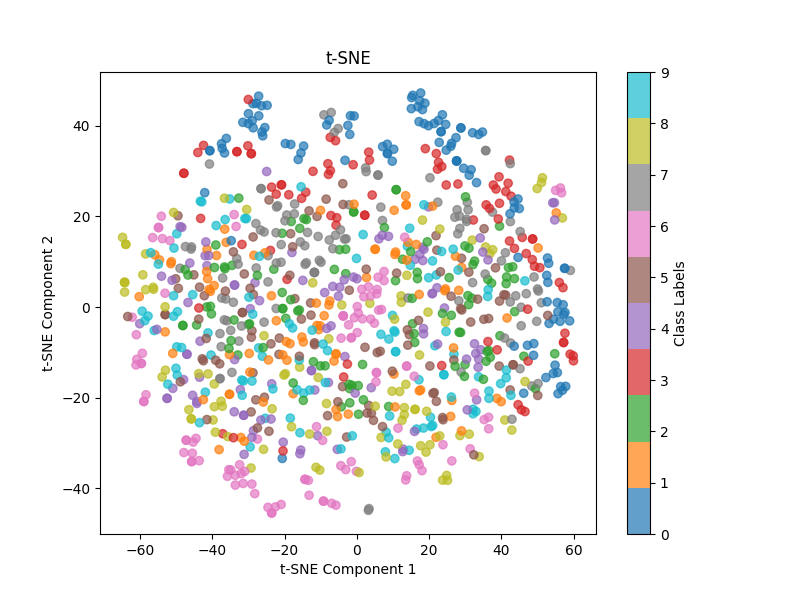

In [11]:
nextplot()
tsne_plot(x_tsne, y)

### t-SNE for embeddings of training data

In [7]:
torch.manual_seed(0)
cnn = SimpleCNN()
_ = train_model(data, cnn)

epoch 0, dt 0.14s, train_loss 1.618e+00, val_loss 1.588e+00, train_acc 37.9, val_acc 35.8
epoch 10, dt 1.23s, train_loss 8.444e-01, val_loss 7.647e-01, train_acc 77.8, val_acc 73.1
epoch 20, dt 1.29s, train_loss 1.535e-01, val_loss 4.929e-01, train_acc 94.5, val_acc 83.9
epoch 30, dt 1.25s, train_loss 2.571e-01, val_loss 5.409e-01, train_acc 96.4, val_acc 87.8
epoch 40, dt 1.27s, train_loss 2.597e-02, val_loss 5.567e-01, train_acc 98.3, val_acc 87.8
epoch 50, dt 1.41s, train_loss 1.436e-01, val_loss 7.377e-01, train_acc 96.8, val_acc 84.9
epoch 60, dt 1.36s, train_loss 5.995e-03, val_loss 7.076e-01, train_acc 99.3, val_acc 89.9
epoch 70, dt 1.31s, train_loss 6.791e-02, val_loss 8.431e-01, train_acc 97.3, val_acc 86.5
epoch 80, dt 1.27s, train_loss 2.734e-03, val_loss 6.274e-01, train_acc 99.9, val_acc 88.9
epoch 90, dt 1.36s, train_loss 3.325e-04, val_loss 6.678e-01, train_acc 100.0, val_acc 90.2
Final result: train_loss 1.653e-04, val_loss 6.678e-01, test_loss 6.433e-01, train_acc 100

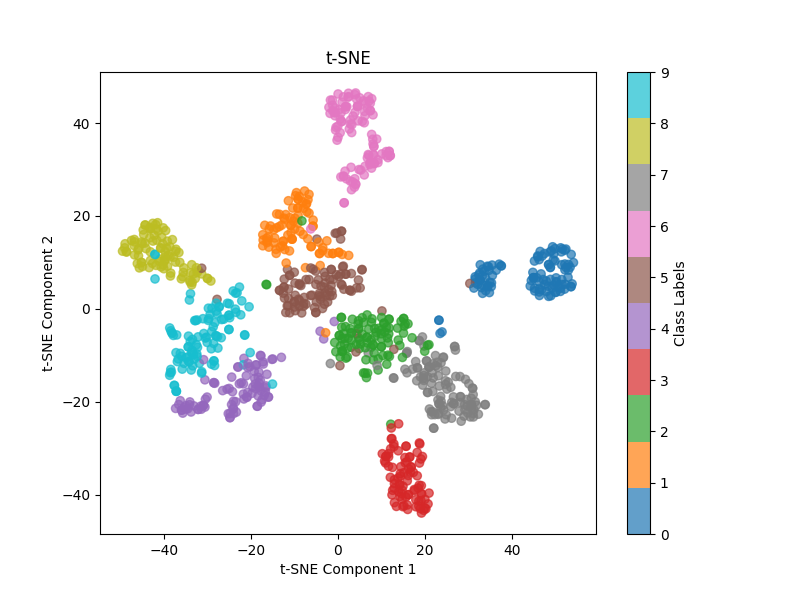

In [8]:
# Before you start, populate `embedding` during the forward pass (in SimpleCNN). It
# should be a list with one element per layer, each being a tensor of form examples x
# embeddings.
cnn.store_embeddings = True
with torch.no_grad():
    cnn(torch.Tensor(x).to(DEVICE))
train_embeddings = [e.cpu().numpy() for e in cnn.embeddings]

# TODO: your code here
# 3d) train + test embeddings
# for 3d i assume that it's still referring to the last layer embeddings
train_tsne = tsne(train_embeddings[1], perplexity=perplexity)
nextplot()
tsne_plot(train_tsne, y)

### t-SNE for embeddings of test data

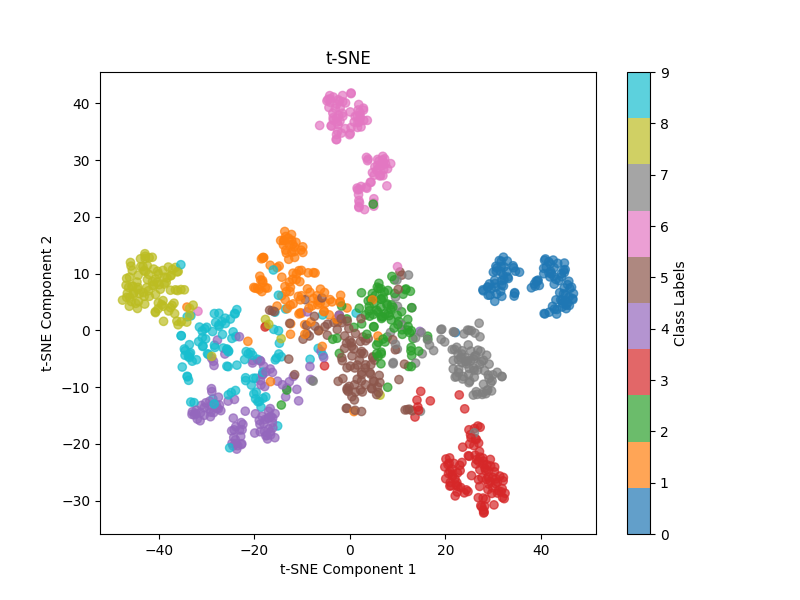

In [9]:
# TODO: your code here

cnn.embeddings = [] 
with torch.no_grad():
    cnn(torch.Tensor(x_test).to(DEVICE))
test_embeddings = [e.cpu().numpy() for e in cnn.embeddings]

test_tsne = tsne(test_embeddings[1], perplexity=perplexity)
nextplot()
tsne_plot(test_tsne, y_test)

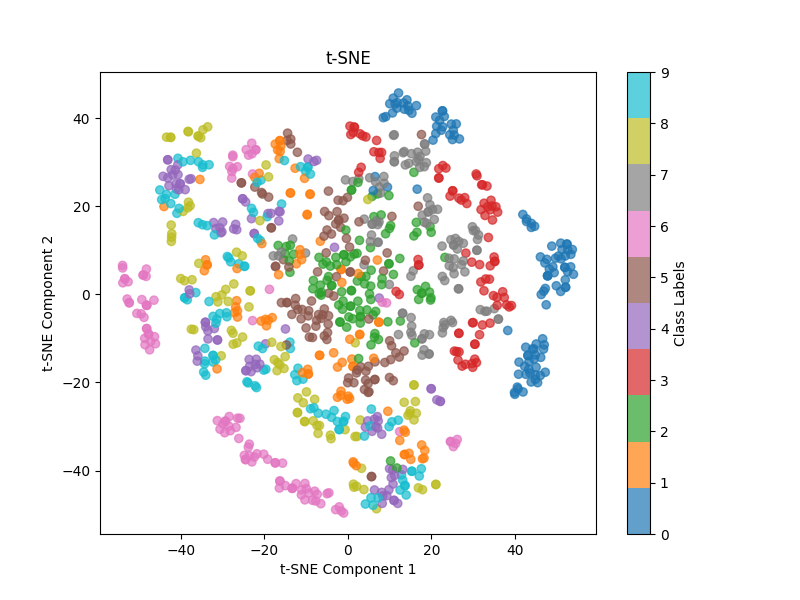

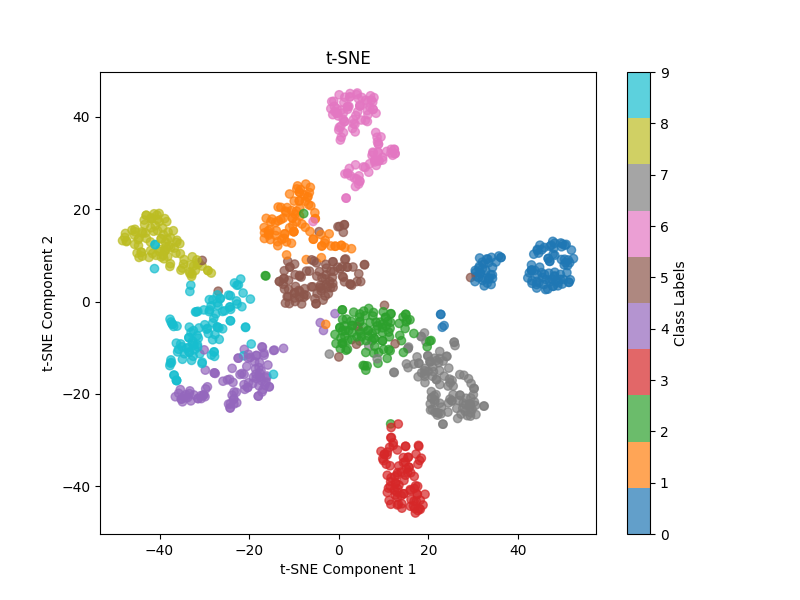

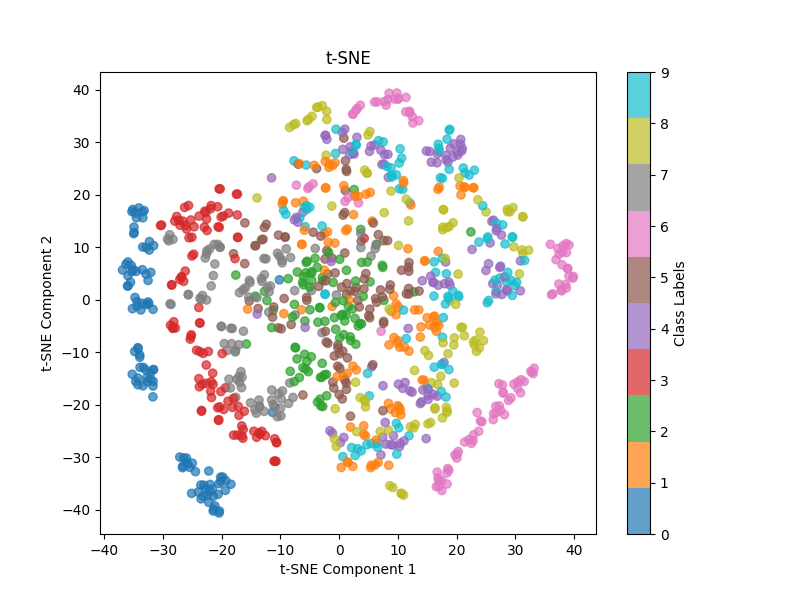

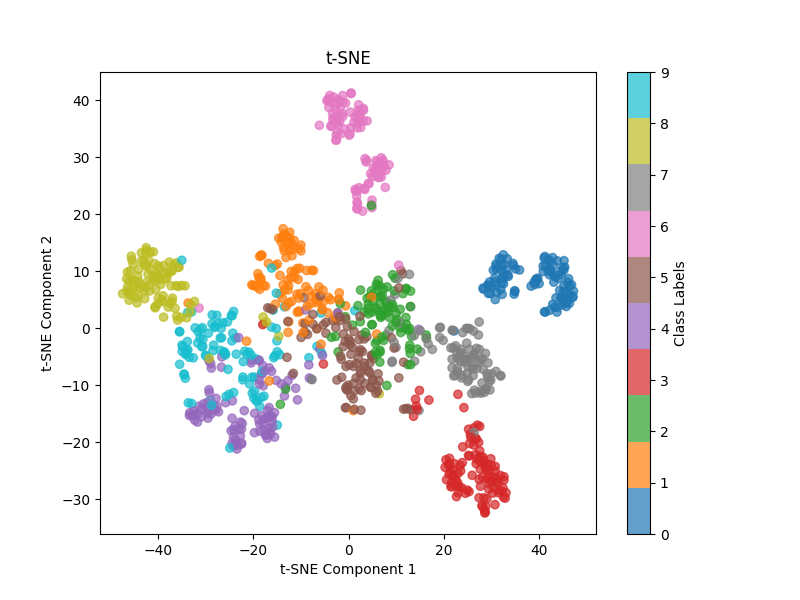

In [10]:
# 3e) different layers
# train layer 1
train_tsne = tsne(train_embeddings[0], perplexity=perplexity)
nextplot()
tsne_plot(train_tsne, y)



# train layer 2
train_tsne = tsne(train_embeddings[1], perplexity=perplexity)
nextplot()
tsne_plot(train_tsne, y)



###################### TEST ########################

# test layer 1
test_tsne = tsne(test_embeddings[0], perplexity=perplexity)
nextplot()
tsne_plot(test_tsne, y_test)

# test layer 2
test_tsne = tsne(test_embeddings[1], perplexity=perplexity)
nextplot()
tsne_plot(test_tsne, y_test)


### Embeddings Heatmap

Following the example below, create a plot that visualizes the average activation
strength over all examples from a certain class `cls` for all features (channels).

It might help to take a look into the plot function `embedding_heatmap`. Let `cls = 0`
for instance, i.e., let us start with the "digit" 0. The dataset (depending on the
seed and generation parameters) contains 419 examples for that digit (approximately
10% of all training examples). Since the length of each "digit" is 40, i.e., 40
*parts*, the input dimensionality is $(419, 1, 40)$. Each example is one dimensional,
i.e., we only have single feature per example. In the first heatmap (*Input*), we
average over all examples and hence see the average value of the only feature (y-axis)
for the individual parts (for each "time step"; x-axis).

After first layer in your CNN (when `stride = 2` and `channels = 25`), the
dimensionality of its output is $(419, 25, 20)$, so the number of parts has halved due
to the stride, but there are now 25 features due to the number of channels.

Now, in the heatmap below, we average over all examples of class `cls`. This means
that the heatmap shows the average activations over all examples of that class `cls`
for all features (y-axis) and parts (x-axis).

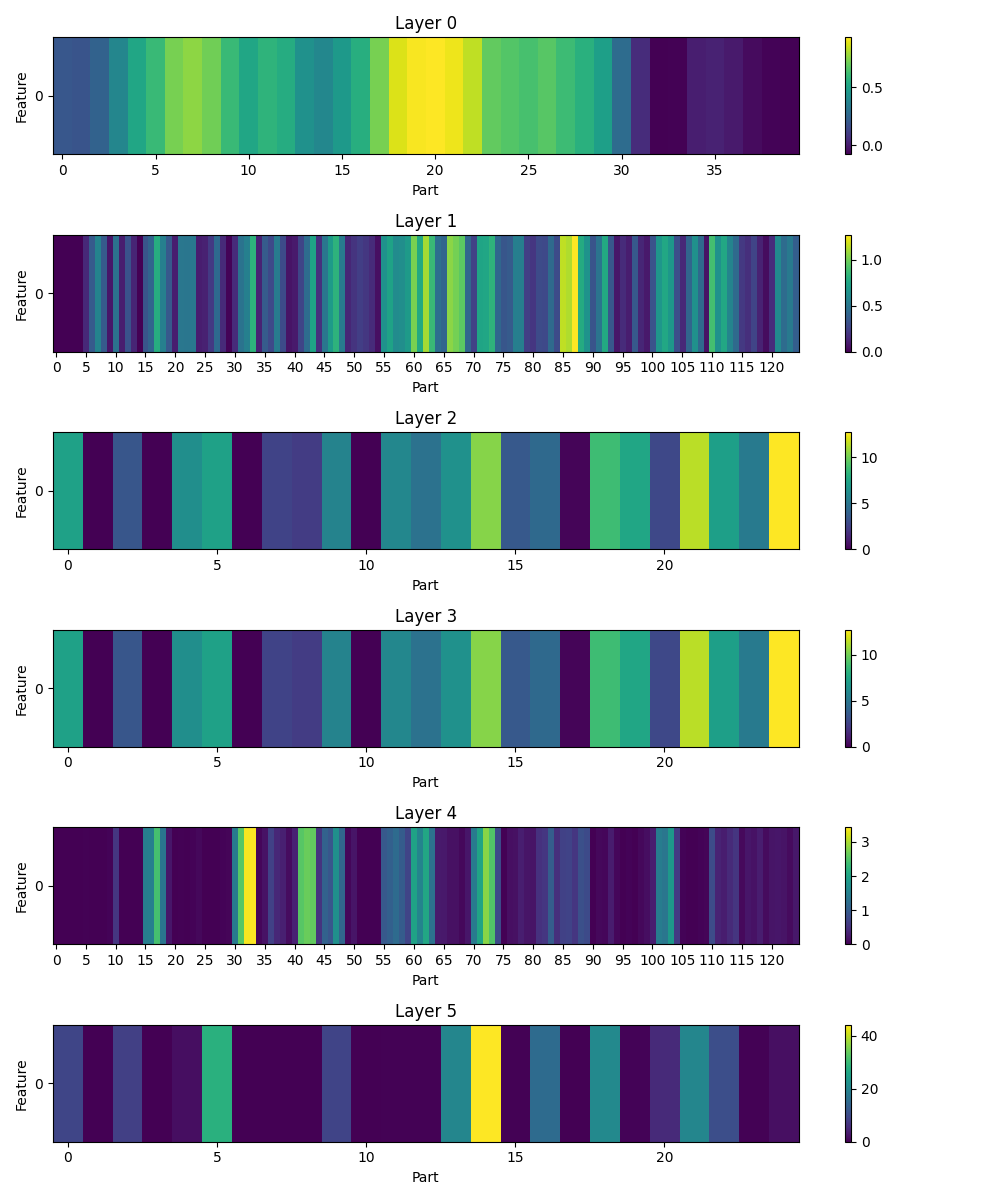

In [9]:
cnn.store_embeddings = True
with torch.no_grad():
    cnn(torch.Tensor(x).to(DEVICE))

train_embeddings = (
    cnn.embeddings
)  # a list of per-layer embeddings, each of form example x embedding

cls = 0  # investigate different classes by changing this index
cls_examples = torch.Tensor(x[y == cls])
cls_train_embeddings = [e[y == cls] for e in train_embeddings]

nextplot()
examples_heatmap([cls_examples] + cls_train_embeddings[:-1])

# TODO: your code here